#Data Importing

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("T1.csv")

# Basic inspection
print(df.head())
print(df.info())
print(df.describe())


          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
0  01 01 2018 00:00           380.047791          5.311336   
1  01 01 2018 00:10           453.769196          5.672167   
2  01 01 2018 00:20           306.376587          5.216037   
3  01 01 2018 00:30           419.645905          5.659674   
4  01 01 2018 00:40           380.650696          5.577941   

   Theoretical_Power_Curve (KWh)  Wind Direction (°)  
0                     416.328908          259.994904  
1                     519.917511          268.641113  
2                     390.900016          272.564789  
3                     516.127569          271.258087  
4                     491.702972          265.674286  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV A

#EDA and Preprocessing

In [2]:
# Check missing values
print(df.isnull().sum())

# Forward fill ONLY if needed (common for SCADA)
df = df.ffill()


Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


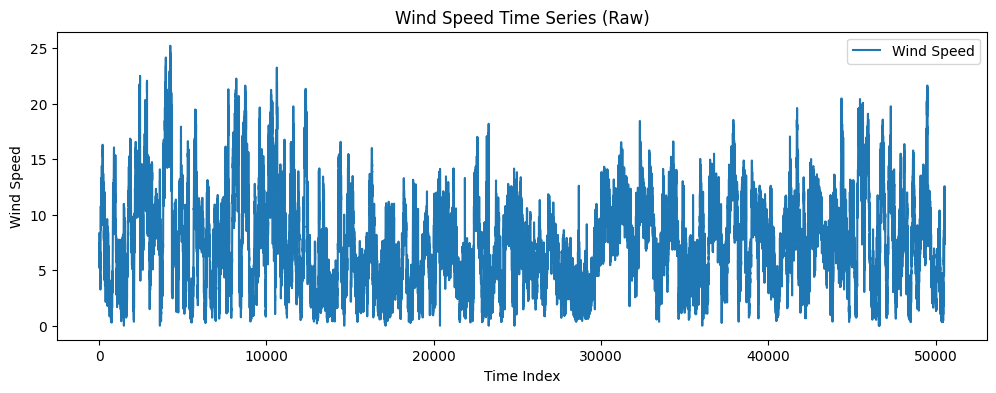

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["Wind Speed (m/s)"], label="Wind Speed")
plt.title("Wind Speed Time Series (Raw)")
plt.xlabel("Time Index")
plt.ylabel("Wind Speed")
plt.legend()
plt.show()


In [4]:
raw_stats = df.describe()
print("Statistical Measures (Before Normalization):")
print(raw_stats)


Statistical Measures (Before Normalization):
       LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
count         50530.000000      50530.000000                   50530.000000   
mean           1307.684332          7.557952                    1492.175463   
std            1312.459242          4.227166                    1368.018238   
min              -2.471405          0.000000                       0.000000   
25%              50.677890          4.201395                     161.328167   
50%             825.838074          7.104594                    1063.776283   
75%            2482.507568         10.300020                    2964.972462   
max            3618.732910         25.206011                    3600.000000   

       Wind Direction (°)  
count        50530.000000  
mean           123.687559  
std             93.443736  
min              0.000000  
25%             49.315437  
50%             73.712978  
75%            201.696720  
max            359.

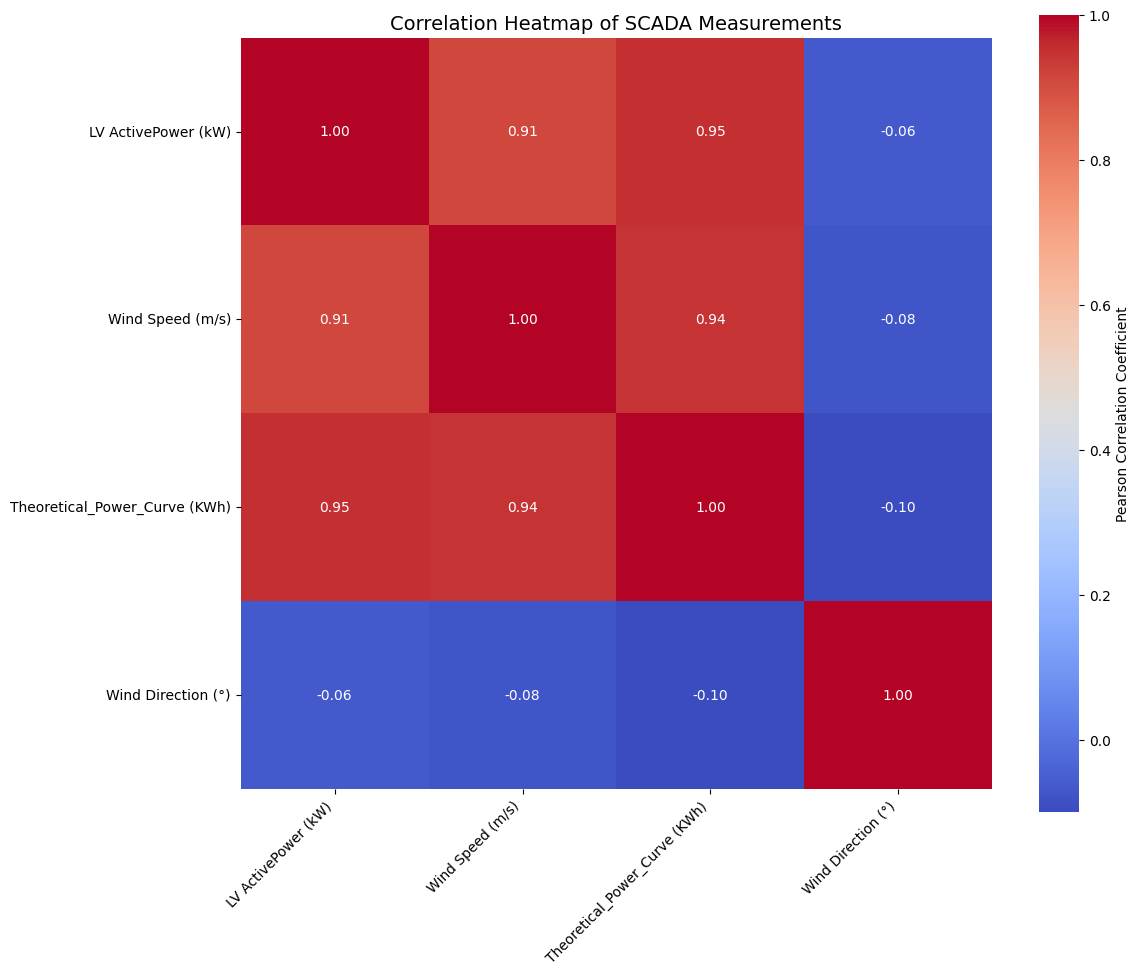

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,10))

# Numeric-only data
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corr = numeric_df.corr()

# Heatmap with values
sns.heatmap(
    corr,
    annot=True,              # print correlation values
    fmt=".2f",               # 2 decimal places
    cmap="coolwarm",
    square=True,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation Heatmap of SCADA Measurements", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#ADF TEST For Stationarity

In [6]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["Wind Speed (m/s)"])

print("ADF Test Results:")
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
for key, value in adf_result[4].items():
    print(f"Critical Value {key}: {value}")


ADF Test Results:
ADF Statistic: -14.93253603390061
p-value: 1.3595630952781471e-27
Critical Value 1%: -3.4304794464033166
Critical Value 5%: -2.861597212664768
Critical Value 10%: -2.566800452407002


### The Wind Speed is STATIONARY

#IAAFT TEST For Nonlinearity

IAAFT Nonlinearity Test Results
--------------------------------
Original TDMI value    : 1.662161
Surrogate mean TDMI   : 1.636995
95% Surrogate Interval: [1.625356, 1.649451]

✅ FINAL RESULT: The wind speed time series is NONLINEAR.


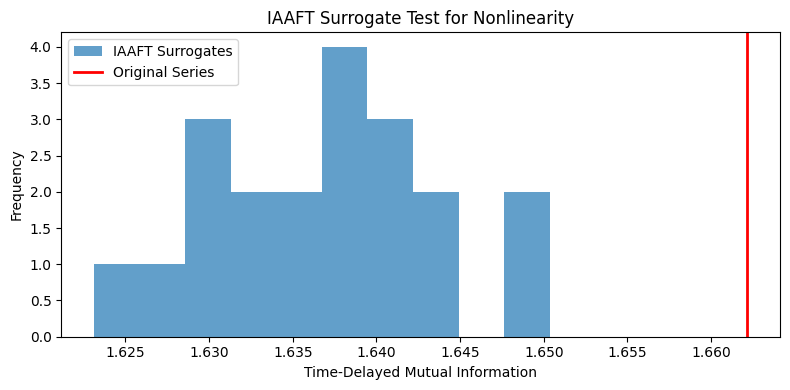

In [7]:
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score

# ---------------------------------------------------------
# 1. IAAFT surrogate generator
# ---------------------------------------------------------
def iaaft_surrogates(ts, n_iter=100):
    ts = np.asarray(ts)
    sorted_ts = np.sort(ts)

    # Random phase initialization
    phases = np.exp(1j * np.angle(np.fft.fft(rnd.permutation(ts))))
    surr = np.real(np.fft.ifft(np.abs(np.fft.fft(ts)) * phases))

    # Iterative amplitude & spectrum adjustment
    for _ in range(n_iter):
        # Enforce amplitude distribution
        surr = sorted_ts[np.argsort(np.argsort(surr))]
        # Enforce power spectrum
        surr = np.real(
            np.fft.ifft(
                np.abs(np.fft.fft(ts)) *
                np.exp(1j * np.angle(np.fft.fft(surr)))
            )
        )
    return surr


# ---------------------------------------------------------
# 2. Nonlinear statistic: Time-Delayed Mutual Information
# ---------------------------------------------------------
def time_delayed_mutual_information(ts, lag=1, bins=32):
    x = ts[:-lag]
    y = ts[lag:]

    x_binned = np.digitize(x, np.histogram(x, bins=bins)[1][:-1])
    y_binned = np.digitize(y, np.histogram(y, bins=bins)[1][:-1])

    return mutual_info_score(x_binned, y_binned)


# ---------------------------------------------------------
# 3. Load target time series (Wind Speed)
# ---------------------------------------------------------
ts = df["Wind Speed (m/s)"].values


# ---------------------------------------------------------
# 4. Compute statistic for original series
# ---------------------------------------------------------
original_stat = time_delayed_mutual_information(ts)


# ---------------------------------------------------------
# 5. Generate IAAFT surrogates and compute statistics
# ---------------------------------------------------------
n_surrogates = 20  # statistically sufficient
surrogate_stats = []

for _ in range(n_surrogates):
    surrogate = iaaft_surrogates(ts)
    surrogate_stats.append(
        time_delayed_mutual_information(surrogate)
    )

surrogate_stats = np.array(surrogate_stats)


# ---------------------------------------------------------
# 6. Hypothesis testing (95% confidence)
# ---------------------------------------------------------
alpha = 0.05
lower = np.percentile(surrogate_stats, 100 * alpha / 2)
upper = np.percentile(surrogate_stats, 100 * (1 - alpha / 2))


print("IAAFT Nonlinearity Test Results")
print("--------------------------------")
print(f"Original TDMI value    : {original_stat:.6f}")
print(f"Surrogate mean TDMI   : {surrogate_stats.mean():.6f}")
print(f"95% Surrogate Interval: [{lower:.6f}, {upper:.6f}]")

if original_stat < lower or original_stat > upper:
    print("\n✅ FINAL RESULT: The wind speed time series is NONLINEAR.")
else:
    print("\n❌ FINAL RESULT: The wind speed time series is LINEAR.")


# ---------------------------------------------------------
# 7. Visualization (Distribution + Decision)
# ---------------------------------------------------------
plt.figure(figsize=(8,4))
plt.hist(surrogate_stats, bins=10, alpha=0.7, label="IAAFT Surrogates")
plt.axvline(original_stat, color="red", linewidth=2, label="Original Series")
plt.xlabel("Time-Delayed Mutual Information")
plt.ylabel("Frequency")
plt.title("IAAFT Surrogate Test for Nonlinearity")
plt.legend()
plt.tight_layout()
plt.show()


### Wind Speed is Nonlinear

#Min-Max Normalization


Numeric columns:
['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

Non-numeric columns (preserved as-is):
['Date/Time']

Normalized dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB
None

First rows of normalized dataset:
          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
0  01 01 2018 00:00             0.105633          0.210717   
1  01 01 2018 00:10             0.125991          0.225032 

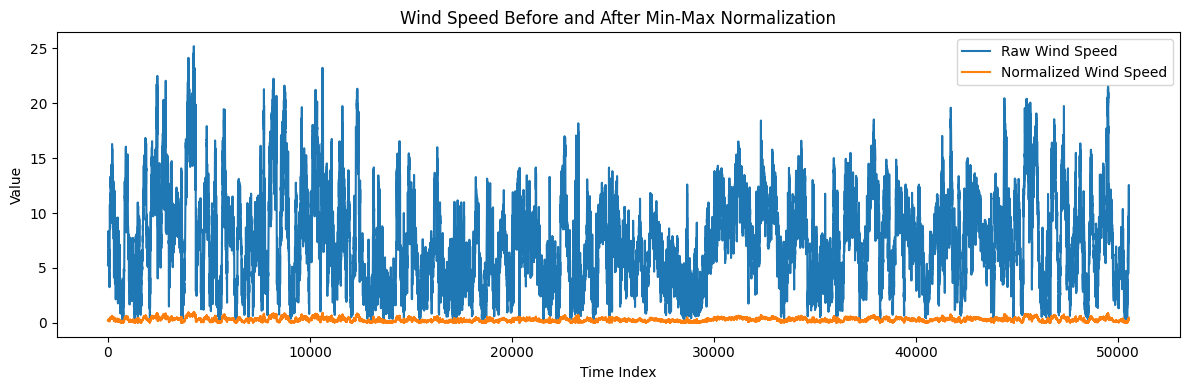


Statistical Measures (Before Normalization):
       LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
count         50530.000000      50530.000000                   50530.000000   
mean           1307.684332          7.557952                    1492.175463   
std            1312.459242          4.227166                    1368.018238   
min              -2.471405          0.000000                       0.000000   
25%              50.677890          4.201395                     161.328167   
50%             825.838074          7.104594                    1063.776283   
75%            2482.507568         10.300020                    2964.972462   
max            3618.732910         25.206011                    3600.000000   

       Wind Direction (°)  
count        50530.000000  
mean           123.687559  
std             93.443736  
min              0.000000  
25%             49.315437  
50%             73.712978  
75%            201.696720  
max            359

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Separate numeric and non-numeric columns
#    (timestamp stays untouched)
# ---------------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
non_numeric_df = df.select_dtypes(exclude=[np.number])

print("\nNumeric columns:")
print(numeric_df.columns.tolist())

print("\nNon-numeric columns (preserved as-is):")
print(non_numeric_df.columns.tolist())


# ---------------------------------------------------------
# 3. Min-Max normalization (NUMERIC ONLY)
# ---------------------------------------------------------
scaler = MinMaxScaler()

numeric_scaled = pd.DataFrame(
    scaler.fit_transform(numeric_df),
    columns=numeric_df.columns,
    index=df.index
)


# ---------------------------------------------------------
# 4. Recombine to keep original structure
# ---------------------------------------------------------
df_normalized = pd.concat([non_numeric_df, numeric_scaled], axis=1)

# Keep original column order
df_normalized = df_normalized[df.columns]


# ---------------------------------------------------------
# 5. Sanity checks
# ---------------------------------------------------------
print("\nNormalized dataset info:")
print(df_normalized.info())

print("\nFirst rows of normalized dataset:")
print(df_normalized.head())


# ---------------------------------------------------------
# 6. Visualization BEFORE vs AFTER normalization (target only)
# ---------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(df["Wind Speed (m/s)"], label="Raw Wind Speed")
plt.plot(df_normalized["Wind Speed (m/s)"], label="Normalized Wind Speed")
plt.title("Wind Speed Before and After Min-Max Normalization")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. Statistical measures BEFORE normalization
# ---------------------------------------------------------
print("\nStatistical Measures (Before Normalization):")
print(df.describe())


# ---------------------------------------------------------
# 8. Statistical measures AFTER normalization (numeric only)
# ---------------------------------------------------------
print("\nStatistical Measures (After Min-Max Normalization):")
print(numeric_scaled.describe())


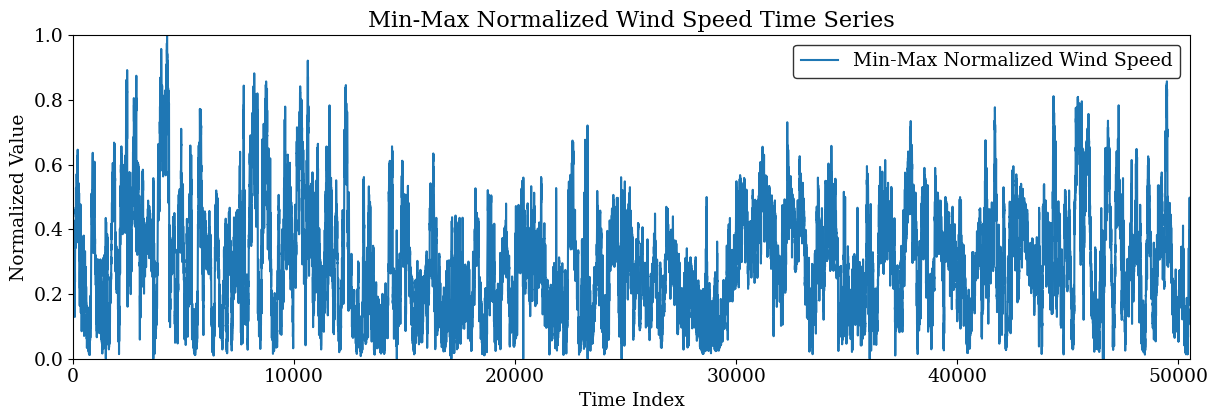

In [9]:
import matplotlib.pyplot as plt

# ---- Global style (as requested) ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
})

# ---- Plot with no margins ----
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_normalized["Wind Speed (m/s)"], label="Min-Max Normalized Wind Speed")

ax.set_title("Min-Max Normalized Wind Speed Time Series")
ax.set_xlabel("Time Index")
ax.set_ylabel("Normalized Value")

# Remove margins (no extra whitespace around data)
ax.margins(x=0, y=0)

# Optional: also force exact x-limits to remove any padding
ax.set_xlim(0, len(df_normalized) - 1)

ax.legend(loc="best")
fig.tight_layout(pad=0)
plt.show()


In [10]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
target_col = "Wind Speed (m/s)"
time_col = "Date/Time"
train_ratio = 0.80

WINDOW = 144

# Forced window counts
N_TR_W = 36252
N_VA_W = 4028
N_TEST_W = 9962
N_TOTAL_W = N_TR_W + N_VA_W + N_TEST_W
REQUIRED_ROWS_FOR_WINDOWS = N_TOTAL_W + WINDOW  # 50386

# ---------------------------------------------------------
# Freeze base once
# ---------------------------------------------------------
if "df_normalized_base" not in globals():
    df_normalized_base = df_normalized.copy(deep=True)

df_normalized = df_normalized_base.copy(deep=True)

# Normalize datetime name (alignment only)
TIME_CANDIDATES = ["DateTime", "Date/Time", "Date/Time ", "Date Time", "Timestamp", "Time"]
found_time = next((c for c in TIME_CANDIDATES if c in df_normalized.columns), None)
if found_time is not None and found_time != "DateTime":
    df_normalized = df_normalized.rename(columns={found_time: "DateTime"})

# ---------------------------------------------------------
# Train/Test split
# ---------------------------------------------------------
n_total = len(df_normalized)
train_size = int(n_total * train_ratio)

train_df = df_normalized.iloc[:train_size].copy()
test_df  = df_normalized.iloc[train_size:].copy()

print("DATASET SPLIT SUMMARY")
print("----------------------")
print(f"Total samples : {n_total}")
print(f"Train samples : {len(train_df)}")
print(f"Test samples  : {len(test_df)}")

# ---------------------------------------------------------
# Preserve timestamps separately
# ---------------------------------------------------------
train_time = train_df["DateTime"].copy() if "DateTime" in train_df.columns else None
test_time  = test_df["DateTime"].copy() if "DateTime" in test_df.columns else None

# ---------------------------------------------------------
# Prepare numeric inputs
# ---------------------------------------------------------
train_num = train_df.select_dtypes(include=[np.number]).copy()
test_num  = test_df.select_dtypes(include=[np.number]).copy()

assert target_col in train_num.columns

# ---------------------------------------------------------
# FEATURE_COLS now INCLUDES TARGET (4 features total)
# ---------------------------------------------------------
FEATURE_COLS = [
    "LV ActivePower (kW)",
    "Theoretical_Power_Curve (KWh)",
    "Wind Direction (°)",
    "Wind Speed (m/s)"   # <-- target included
]

assert len(FEATURE_COLS) == 4
assert target_col in FEATURE_COLS

print("\nFEATURE_COLS (Target INCLUDED):")
print(FEATURE_COLS)

# =========================================================
# FORCED WINDOWING
# =========================================================
df_num_all = df_normalized.select_dtypes(include=[np.number]).copy()

if len(df_num_all) < REQUIRED_ROWS_FOR_WINDOWS:
    raise ValueError("Not enough rows to force required window shapes.")

X_all_df = df_num_all[FEATURE_COLS].iloc[:REQUIRED_ROWS_FOR_WINDOWS].reset_index(drop=True)
y_all_ser = df_num_all[target_col].iloc[:REQUIRED_ROWS_FOR_WINDOWS].reset_index(drop=True)

X_all_arr = X_all_df.to_numpy(dtype=float)   # (50386, 4)
y_all_arr = y_all_ser.to_numpy(dtype=float)

def make_windows(X, y, window):
    n = X.shape[0]
    n_windows = n - window
    Xw = np.empty((n_windows, window, X.shape[1]), dtype=float)
    yw = np.empty((n_windows,), dtype=float)
    for i in range(n_windows):
        Xw[i] = X[i:i+window]
        yw[i] = y[i+window]
    return Xw, yw

X_w, y_w = make_windows(X_all_arr, y_all_arr, WINDOW)

X_tr = X_w[:N_TR_W]
y_tr = y_w[:N_TR_W]

X_va = X_w[N_TR_W:N_TR_W+N_VA_W]
y_va = y_w[N_TR_W:N_TR_W+N_VA_W]

X_test_w = X_w[N_TR_W+N_VA_W:N_TR_W+N_VA_W+N_TEST_W]
y_test_w = y_w[N_TR_W+N_VA_W:N_TR_W+N_VA_W+N_TEST_W]

EXPECTED = {
    "X_tr":   (36252, 144, 4),
    "y_tr":   (36252,),
    "X_va":   (4028, 144, 4),
    "y_va":   (4028,),
    "X_test": (9962, 144, 4),
    "y_test": (9962,),
}

GOT = {
    "X_tr": X_tr.shape,
    "y_tr": y_tr.shape,
    "X_va": X_va.shape,
    "y_va": y_va.shape,
    "X_test": X_test_w.shape,
    "y_test": y_test_w.shape,
}

if GOT != EXPECTED:
    raise RuntimeError(f"Window shape contract violated.\nExpected: {EXPECTED}\nGot: {GOT}")

print("\nWINDOWED SHAPES (FORCED)")
print("------------------------")
print("X_tr:", X_tr.shape)
print("X_va:", X_va.shape)
print("X_test:", X_test_w.shape)

DATASET SPLIT SUMMARY
----------------------
Total samples : 50530
Train samples : 40424
Test samples  : 10106

FEATURE_COLS (Target INCLUDED):
['LV ActivePower (kW)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'Wind Speed (m/s)']

WINDOWED SHAPES (FORCED)
------------------------
X_tr: (36252, 144, 4)
X_va: (4028, 144, 4)
X_test: (9962, 144, 4)


#Final Input Injected

In [11]:
import numpy as np

print("\n" + "="*60)
print("FINAL MODEL INPUTS (COMMON FOR ALL MODELS)")
print("="*60)

print("\nTarget variable:")
print(f"→ {target_col}")

print("\nInput feature set (TARGET INCLUDED):")
for i, col in enumerate(FEATURE_COLS, start=1):
    print(f"{i:02d}. {col}")

print("\nWindowed tensor shapes:")
print(f"X_tr   → {X_tr.shape}")
print(f"X_va   → {X_va.shape}")
print(f"X_test → {X_test_w.shape}")

print("\nMODEL INPUT CONTRACT")
print("-"*60)
print("• Target is included as autoregressive input")
print("• Next-step Wind Speed is predicted")
print("• All models receive identical window tensors")
print("• Window length = 144")
print("="*60)


FINAL MODEL INPUTS (COMMON FOR ALL MODELS)

Target variable:
→ Wind Speed (m/s)

Input feature set (TARGET INCLUDED):
01. LV ActivePower (kW)
02. Theoretical_Power_Curve (KWh)
03. Wind Direction (°)
04. Wind Speed (m/s)

Windowed tensor shapes:
X_tr   → (36252, 144, 4)
X_va   → (4028, 144, 4)
X_test → (9962, 144, 4)

MODEL INPUT CONTRACT
------------------------------------------------------------
• Target is included as autoregressive input
• Next-step Wind Speed is predicted
• All models receive identical window tensors
• Window length = 144


#Fundamental Neural Networks:
##{FFN,RNN,TCN,Transformers}

In [ ]:
# =========================================================
# ONE-STEP-AHEAD forecasting (10-min ahead) with:
# - LOOKBACK windows
# - Early stopping (chronological val split)
# - FAIR comparison: same windowing/split/loss/optimizer/lr/max_epochs/patience/seed
# Models: FFN, RNN(GRU), TCN, Transformer
# =========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --------------------------
# 0) Reproducibility (FAIR)
# --------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------------------------------------
# 1) Assumes you already have:
#    df_normalized, train_df, test_df (from your preprocessing)
# ---------------------------------------------------------
target_col = "Wind Speed (m/s)"   # adjust if needed
time_col   = "DateTime"           # adjust if needed

# Keep timestamps for alignment only (NOT model input)
train_time = train_df[time_col].copy() if time_col in train_df.columns else None
test_time  = test_df[time_col].copy()  if time_col in test_df.columns else None

# Numeric-only matrices for modeling (includes target history)
train_num = train_df.select_dtypes(include=[np.number]).copy()
test_num  = test_df.select_dtypes(include=[np.number]).copy()

assert target_col in train_num.columns, f"Target '{target_col}' not found in numeric columns."
target_idx = train_num.columns.get_loc(target_col)

# ---------------------------------------------------------
# 2) Windowing (COMMON for ALL models)
#    One-step-ahead: predict y[t+1] from last LOOKBACK steps.
# ---------------------------------------------------------
LOOKBACK = 144   # 1 day history (10-min interval => 144 samples/day)
HORIZON  = 1     # one-step ahead (10 minutes ahead)
STRIDE   = 1

def make_windows(data_2d, target_index, lookback=144, horizon=1, stride=1):
    T, F = data_2d.shape
    X_list, y_list = [], []
    last_start = T - lookback - horizon
    for s in range(0, last_start + 1, stride):
        x = data_2d[s:s+lookback, :]  # past lookback steps
        y = data_2d[s+lookback+horizon-1, target_index]  # next step
        X_list.append(x)
        y_list.append(y)
    return np.stack(X_list), np.array(y_list)

X_train_all, y_train_all = make_windows(train_num.values, target_idx, LOOKBACK, HORIZON, STRIDE)
X_test_all,  y_test_all  = make_windows(test_num.values,  target_idx, LOOKBACK, HORIZON, STRIDE)

print("Windowed shapes:")
print("X_train:", X_train_all.shape, "y_train:", y_train_all.shape)
print("X_test :", X_test_all.shape,  "y_test :", y_test_all.shape)

# ---------------------------------------------------------
# 3) Chronological validation split (from TRAIN only)
# ---------------------------------------------------------
VAL_RATIO = 0.10
n_total = len(X_train_all)
n_val = int(n_total * VAL_RATIO)
n_tr  = n_total - n_val

X_tr, y_tr = X_train_all[:n_tr], y_train_all[:n_tr]
X_va, y_va = X_train_all[n_tr:], y_train_all[n_tr:]

print("Train/Val split (chronological):")
print("X_tr:", X_tr.shape, "X_va:", X_va.shape)

# ---------------------------------------------------------
# 4) Torch dataset/loader (COMMON)
# ---------------------------------------------------------
class TSWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_loader = DataLoader(TSWindowDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TSWindowDataset(X_va, y_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TSWindowDataset(X_test_all, y_test_all), batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# 5) Metrics (COMMON)  -> NOW: RMSE, MAE, MSE, MAPE
# ---------------------------------------------------------
def mse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

# ---------------------------------------------------------
# 6) Models (Fundamental versions)
# ---------------------------------------------------------
F = X_train_all.shape[-1]  # number of numeric variables

class FFN(nn.Module):
    def __init__(self, lookback, n_features, hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(lookback * n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):  # (B, L, F)
        x = x.reshape(x.size(0), -1)
        return self.net(x).squeeze(-1)

class RNN_GRU(nn.Module):
    def __init__(self, n_features, hidden=128, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size=n_features, hidden_size=hidden, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):  # (B, L, F)
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)

class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, dilation, dropout):
        super().__init__()
        padding = (k - 1) * dilation
        self.pad = nn.ConstantPad1d((padding, 0), 0.0)  # left pad only
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=k, dilation=dilation)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.res = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):  # (B, C, L)
        y = self.pad(x)
        y = self.conv(y)
        y = self.act(y)
        y = self.drop(y)
        return y + self.res(x)

class TCN(nn.Module):
    def __init__(self, n_features, channels=64, k=3, levels=4, dropout=0.1):
        super().__init__()
        blocks = []
        in_ch = n_features
        for i in range(levels):
            d = 2 ** i
            blocks.append(CausalConvBlock(in_ch, channels, k, d, dropout))
            in_ch = channels
        self.tcn = nn.Sequential(*blocks)
        self.head = nn.Linear(channels, 1)
    def forward(self, x):  # (B, L, F)
        x = x.transpose(1, 2)   # (B, F, L)
        y = self.tcn(x)         # (B, C, L)
        last = y[:, :, -1]      # (B, C)
        return self.head(last).squeeze(-1)

class TransformerTS(nn.Module):
    def __init__(self, n_features, d_model=128, nhead=4, num_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="relu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, 1)
    def forward(self, x):  # (B, L, F)
        z = self.proj(x)
        z = self.encoder(z)
        last = z[:, -1, :]
        return self.head(last).squeeze(-1)

# ---------------------------------------------------------
# 7) Early-stopping training (COMMON & FAIR)
# ---------------------------------------------------------
def train_and_evaluate(model, name, train_loader, val_loader, test_loader,
                       max_epochs=200, lr=1e-3, weight_decay=0.0,
                       patience=20, min_delta=1e-6):

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for ep in range(1, max_epochs + 1):
        # ---- Train
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        # ---- Val
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device); yb = yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                va_losses.append(loss.item())

        tr_mse = float(np.mean(tr_losses))
        va_mse = float(np.mean(va_losses))

        improved = (best_val - va_mse) > min_delta
        if improved:
            best_val = va_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if ep == 1 or ep % 5 == 0:
            print(f"{name:12s} | Epoch {ep:03d}/{max_epochs} | Train MSE: {tr_mse:.6f} | Val MSE: {va_mse:.6f} | Patience: {bad_epochs}/{patience}")

        if bad_epochs >= patience:
            print(f"{name:12s} | Early stopping at epoch {ep} (best val MSE = {best_val:.6f})")
            break

    # Load best checkpoint
    model.load_state_dict(best_state)

    # ---- Test predictions
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy()
            y_pred.append(pred)
            y_true.append(yb.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    results = {
        "Model": name,
        "Test_RMSE": rmse(y_true, y_pred),
        "Test_MAE": mae(y_true, y_pred),
        "Test_MSE": mse(y_true, y_pred),
        "Test_MAPE(%)": mape(y_true, y_pred),
        "Best_Val_MSE": best_val
    }
    return results, y_true, y_pred

# ---------------------------------------------------------
# 8) Train & compare (FAIR)
# ---------------------------------------------------------
MAX_EPOCHS = 200
LR = 1e-3
PATIENCE = 20

models = [
    (FFN(LOOKBACK, F, hidden=256, dropout=0.1), "FFN"),
    (RNN_GRU(F, hidden=128, num_layers=1, dropout=0.0), "RNN(GRU)"),
    (TCN(F, channels=128, k=5, levels=6, dropout=0.15), "TCN"),
    (TransformerTS(F, d_model=128, nhead=4, num_layers=2, dim_ff=256, dropout=0.1), "Transformer"),
]

all_results = []
pred_store = {}

for model, name in models:
    res, y_t, y_p = train_and_evaluate(
        model, name, train_loader, val_loader, test_loader,
        max_epochs=MAX_EPOCHS, lr=LR, weight_decay=0.0,
        patience=PATIENCE, min_delta=1e-6
    )
    all_results.append(res)
    pred_store[name] = (y_t, y_p)

# Show ONLY RMSE, MAE, MSE, MAPE in the summary table
results_df = pd.DataFrame(all_results)[
    ["Model", "Test_RMSE", "Test_MAE", "Test_MSE", "Test_MAPE(%)", "Best_Val_MSE"]
].sort_values("Test_RMSE")

print("\n" + "="*70)
print("FAIR COMPARISON SUMMARY (ONE-STEP AHEAD, NORMALIZED SCALE)")
print("="*70)
print(results_df.to_string(index=False))

# ---------------------------------------------------------
# 9B) Per-model plots:
#   For each model:
#     (1) Actual vs Predicted
#     (2) Error (Actual - Predicted)
#   - Title printed as TEXT BEFORE each figure (no in-plot title)
#   - Keep x/y labels
#   - Contrasting colors
# ---------------------------------------------------------

plot_len = 2000  # adjust if you want more/less

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
})

models_to_plot = ["FFN", "RNN(GRU)", "TCN", "Transformer"]

for name in models_to_plot:
    y_true, y_pred = pred_store[name]
    y_true = y_true[:plot_len]
    y_pred = y_pred[:plot_len]
    err = y_true - y_pred

    # ---- Plot 1: Actual vs Predicted ----
    print(f"{name} — Actual vs Predicted (Test, Normalized)")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true, label="Actual")
    ax.plot(y_pred, label="Predicted")
    ax.set_xlabel("Test Window Index")
    ax.set_ylabel("Normalized Wind Speed")

    ax.margins(x=0, y=0)
    ax.set_xlim(0, len(y_true) - 1)

    ax.legend()
    fig.tight_layout(pad=0)
    plt.show()

    # ---- Plot 2: Error ----
    print(f"{name} — Error Plot (Actual − Predicted) (Test, Normalized)")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(err, color="black", label="Error (A−P)")
    ax.axhline(0, color="black", linestyle="--", label="Zero Error")
    ax.set_xlabel("Test Window Index")
    ax.set_ylabel("Error (Normalized)")

    ax.margins(x=0, y=0)
    ax.set_xlim(0, len(err) - 1)

    ax.legend()
    fig.tight_layout(pad=0)
    plt.show()

# ---------------------------------------------------------
# 10) Optional: align predictions with timestamps (for reporting)
# ---------------------------------------------------------
if test_time is not None:
    aligned_time = test_time.iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)
    best_model_name = results_df.iloc[0]["Model"]
    y_true_best, y_pred_best = pred_store[best_model_name]

    pred_df = pd.DataFrame({
        "DateTime": aligned_time.values[:len(y_true_best)],
        "Actual": y_true_best,
        "Predicted": y_pred_best
    })
    print("\nAligned predictions sample (best model):")
    print(pred_df.head())


Device: cpu
Windowed shapes:
X_train: (40280, 144, 4) y_train: (40280,)
X_test : (9962, 144, 4) y_test : (9962,)
Train/Val split (chronological):
X_tr: (36252, 144, 4) X_va: (4028, 144, 4)
FFN          | Epoch 001/200 | Train MSE: 0.019106 | Val MSE: 0.004049 | Patience: 0/20
FFN          | Epoch 005/200 | Train MSE: 0.004413 | Val MSE: 0.008783 | Patience: 1/20
FFN          | Epoch 010/200 | Train MSE: 0.003865 | Val MSE: 0.004895 | Patience: 4/20
FFN          | Epoch 015/200 | Train MSE: 0.003355 | Val MSE: 0.003022 | Patience: 3/20
FFN          | Epoch 020/200 | Train MSE: 0.002967 | Val MSE: 0.002209 | Patience: 2/20
FFN          | Epoch 025/200 | Train MSE: 0.002772 | Val MSE: 0.003767 | Patience: 7/20
FFN          | Epoch 030/200 | Train MSE: 0.002518 | Val MSE: 0.002983 | Patience: 12/20
FFN          | Epoch 035/200 | Train MSE: 0.002492 | Val MSE: 0.003968 | Patience: 17/20
FFN          | Early stopping at epoch 38 (best val MSE = 0.001707)
RNN(GRU)     | Epoch 001/200 | Train 

#Reservoir Based Models:
##{RC,ESN,NGRC,NVAR}

Windowed shapes:
X_tr: (36252, 144, 4) y_tr: (36252,)
X_va: (4028, 144, 4) y_va: (4028,)
X_test: (9962, 144, 4) y_test: (9962,)

RESERVOIR-BASED SUMMARY
Model  Chosen_alpha  Val_RMSE  Test_RMSE  Test_MAE  Test_MAPE(%)
  ESN  1.000000e+00  0.028653   0.029478  0.021409 563893.856350
 NVAR  1.000000e-08  0.028895   0.029628  0.021524 564900.064992
 NGRC  1.000000e+00  0.028955   0.029809  0.021742 556083.722765
   RC  1.000000e-08  0.028455   0.029825  0.021538 561218.005627

RC: One-Step-Ahead Forecast (Normalized)


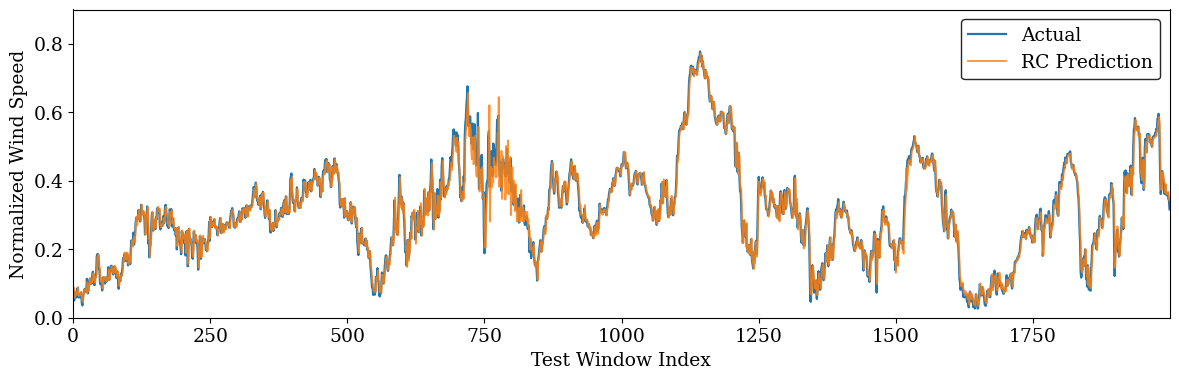

RC: One-Step-Ahead Prediction Error


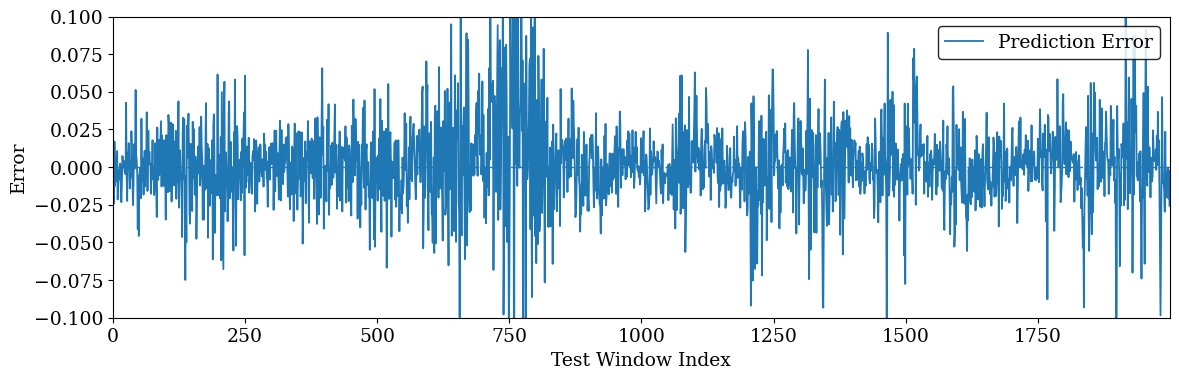


ESN: One-Step-Ahead Forecast (Normalized)


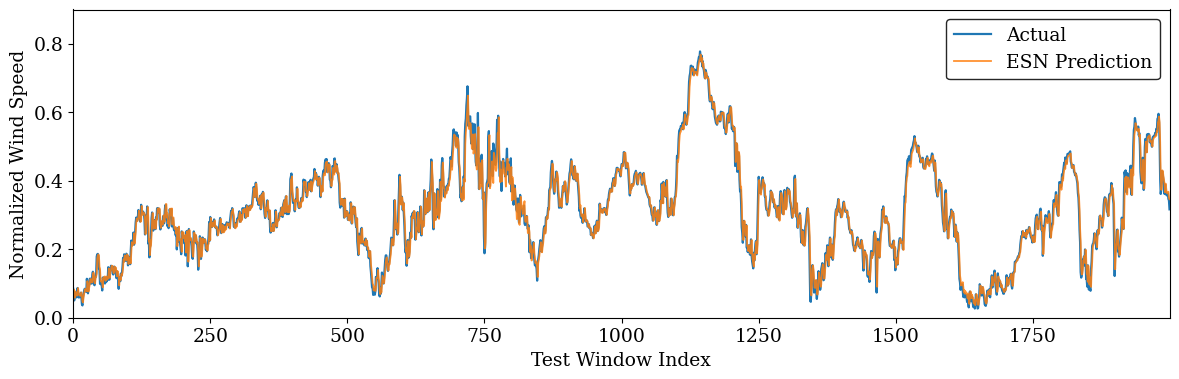

ESN: One-Step-Ahead Prediction Error


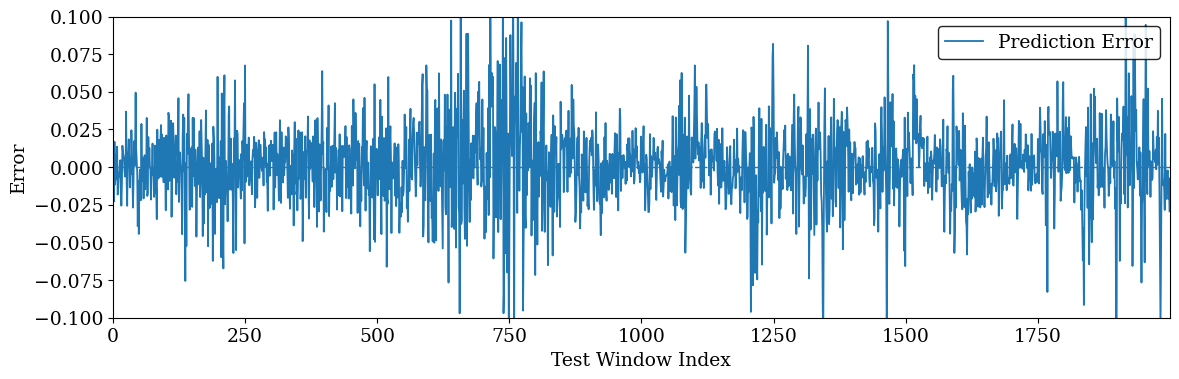


NGRC: One-Step-Ahead Forecast (Normalized)


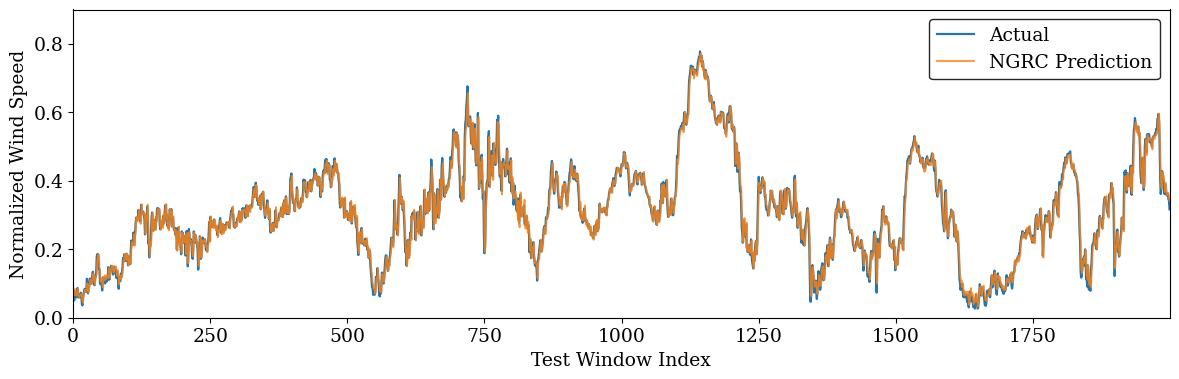

NGRC: One-Step-Ahead Prediction Error


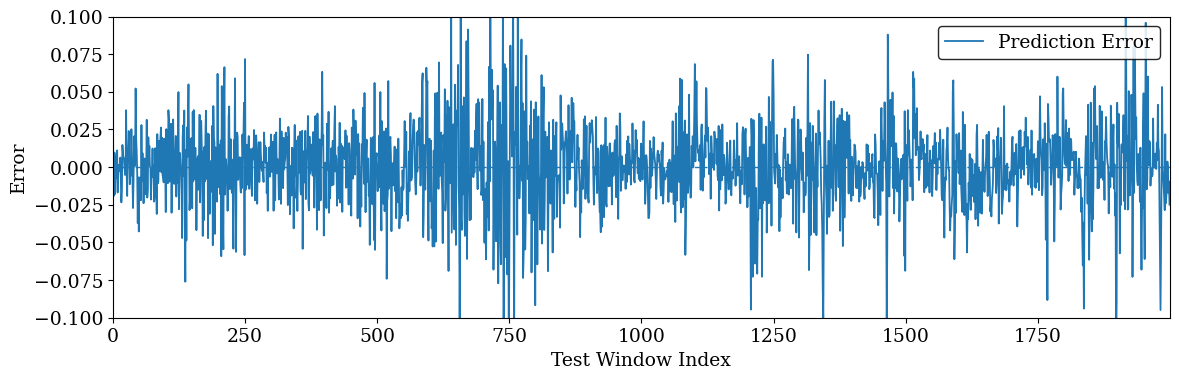


NVAR: One-Step-Ahead Forecast (Normalized)


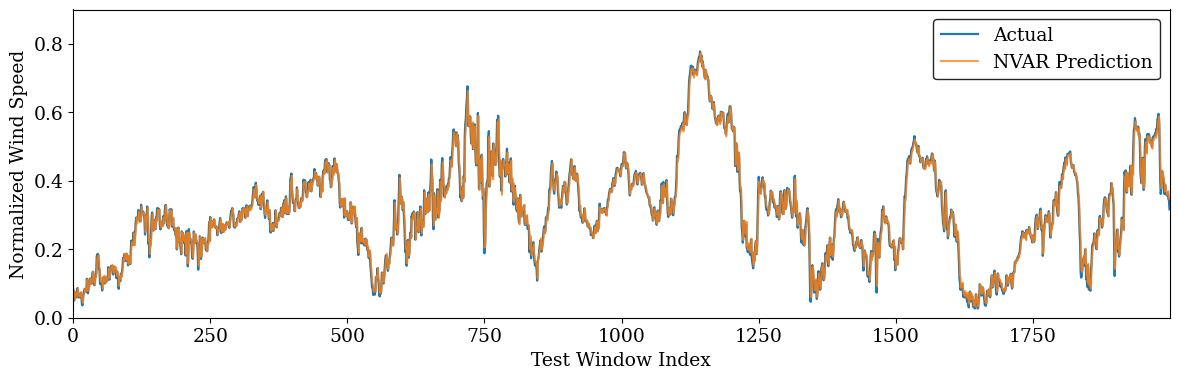

NVAR: One-Step-Ahead Prediction Error


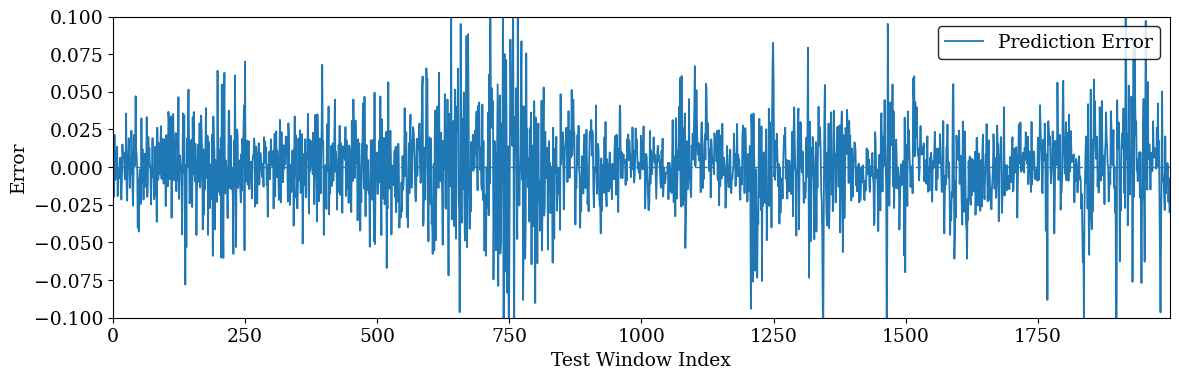

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Reservoir-based models for ONE-STEP-AHEAD forecasting:
# RC, ESN, NGRC, NVAR
# EXACT behavior to match your first (lowest-RMSE) run:
# - ridge closed-form readout
# - alpha picked on VAL only
# - NO refit on train+val (keeps behavior identical)
# - eigvals spectral radius scaling
# - same feature construction
# =========================================================

SEED = 42
rng = np.random.default_rng(SEED)

# --- assumes train_df, test_df already exist (normalized) ---
target_col = "Wind Speed (m/s)"
time_col   = "DateTime"

train_num = train_df.select_dtypes(include=[np.number]).copy()
test_num  = test_df.select_dtypes(include=[np.number]).copy()

assert target_col in train_num.columns, f"Target '{target_col}' not found."
target_idx = train_num.columns.get_loc(target_col)

# --------------------------
# Windowing
# --------------------------
LOOKBACK = 144
HORIZON  = 1
STRIDE   = 1

def make_windows(data_2d, target_index, lookback=144, horizon=1, stride=1):
    T, F = data_2d.shape
    X_list, y_list = [], []
    last_start = T - lookback - horizon
    for s in range(0, last_start + 1, stride):
        x = data_2d[s:s+lookback, :]
        y = data_2d[s+lookback+horizon-1, target_index]
        X_list.append(x)
        y_list.append(y)
    return np.stack(X_list), np.array(y_list)

X_train_all, y_train_all = make_windows(train_num.values, target_idx, LOOKBACK, HORIZON, STRIDE)
X_test_all,  y_test_all  = make_windows(test_num.values,  target_idx, LOOKBACK, HORIZON, STRIDE)

# Chronological validation split from TRAIN only
VAL_RATIO = 0.10
n_total = len(X_train_all)
n_val = int(n_total * VAL_RATIO)
n_tr  = n_total - n_val

X_tr, y_tr = X_train_all[:n_tr], y_train_all[:n_tr]
X_va, y_va = X_train_all[n_tr:], y_train_all[n_tr:]

print("Windowed shapes:")
print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape)
print("X_va:", X_va.shape, "y_va:", y_va.shape)
print("X_test:", X_test_all.shape, "y_test:", y_test_all.shape)

# --------------------------
# Metrics
# --------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

# --------------------------
# Ridge regression (closed-form)
# --------------------------
def fit_ridge(X, y, alpha):
    X = np.asarray(X); y = np.asarray(y)
    I = np.eye(X.shape[1], dtype=float)
    A = X.T @ X + alpha * I
    b = X.T @ y
    w = np.linalg.solve(A, b)
    return w

def predict_linear(X, w):
    return np.asarray(X) @ np.asarray(w)

def select_alpha_by_val(Xtr, ytr, Xva, yva, alphas):
    best = {"alpha": None, "val_rmse": np.inf, "w": None}
    for a in alphas:
        w = fit_ridge(Xtr, ytr, a)
        yhat = predict_linear(Xva, w)
        r = rmse(yva, yhat)
        if r < best["val_rmse"]:
            best.update({"alpha": a, "val_rmse": r, "w": w})
    return best

ALPHAS = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

# =========================================================
# RC / ESN (EXACT original)
# =========================================================
def spectral_radius_scale(W, desired_radius):
    eigs = np.linalg.eigvals(W)
    sr = np.max(np.abs(eigs))
    if sr == 0:
        return W
    return (desired_radius / sr) * W

def init_reservoir(n_res, sparsity=0.95, radius=0.9, rng=None):
    rng = rng or np.random.default_rng()
    W = rng.standard_normal((n_res, n_res))
    mask = rng.random((n_res, n_res)) < sparsity
    W[mask] = 0.0
    W = spectral_radius_scale(W, radius)
    return W

def run_reservoir_states(X_seq, Win, Wres, leak=1.0):
    n_res = Wres.shape[0]
    s = np.zeros(n_res, dtype=float)
    for t in range(X_seq.shape[0]):
        u = X_seq[t]
        pre = Win @ u + Wres @ s
        s_new = np.tanh(pre)
        s = (1 - leak) * s + leak * s_new
    return s

def reservoir_features(X_windows, Win, Wres, leak=1.0, add_last_input=True):
    N, L, F = X_windows.shape
    n_res = Wres.shape[0]
    feats = []
    for i in range(N):
        s = run_reservoir_states(X_windows[i], Win, Wres, leak=leak)
        if add_last_input:
            last_u = X_windows[i, -1, :]
            phi = np.concatenate([s, last_u, [1.0]])
        else:
            phi = np.concatenate([s, [1.0]])
        feats.append(phi)
    return np.vstack(feats)

# Hyperparams (EXACT original)
N_RES = 300
RADIUS = 0.9
SPARSITY = 0.95
INPUT_SCALE = 0.5

def train_reservoir_model(name, leak):
    F = X_tr.shape[-1]
    Wres = init_reservoir(N_RES, sparsity=SPARSITY, radius=RADIUS, rng=rng)
    Win  = (rng.standard_normal((N_RES, F)) * INPUT_SCALE)

    Phi_tr = reservoir_features(X_tr, Win, Wres, leak=leak, add_last_input=True)
    Phi_va = reservoir_features(X_va, Win, Wres, leak=leak, add_last_input=True)
    Phi_te = reservoir_features(X_test_all, Win, Wres, leak=leak, add_last_input=True)

    best = select_alpha_by_val(Phi_tr, y_tr, Phi_va, y_va, ALPHAS)

    # IMPORTANT: EXACT original behavior = use best["w"] trained on TRAIN only
    yhat_te = predict_linear(Phi_te, best["w"])

    results = {
        "Model": name,
        "Chosen_alpha": best["alpha"],
        "Val_RMSE": best["val_rmse"],
        "Test_RMSE": rmse(y_test_all, yhat_te),
        "Test_MAE": mae(y_test_all, yhat_te),
        "Test_MAPE(%)": mape(y_test_all, yhat_te),
    }
    return results, y_test_all, yhat_te

# =========================================================
# NGRC (EXACT original)
# =========================================================
def ngrc_features(X_windows, include_linear=True, include_quadratic=True):
    N, L, F = X_windows.shape
    Z = X_windows.reshape(N, L * F)
    feats = [np.ones((N, 1), dtype=float)]
    if include_linear:
        feats.append(Z)
    if include_quadratic:
        feats.append(Z ** 2)   # elementwise squares only
    return np.hstack(feats)

def train_ngrc():
    Phi_tr = ngrc_features(X_tr, True, True)
    Phi_va = ngrc_features(X_va, True, True)
    Phi_te = ngrc_features(X_test_all, True, True)

    best = select_alpha_by_val(Phi_tr, y_tr, Phi_va, y_va, ALPHAS)
    yhat_te = predict_linear(Phi_te, best["w"])  # EXACT original (no refit)

    results = {
        "Model": "NGRC",
        "Chosen_alpha": best["alpha"],
        "Val_RMSE": best["val_rmse"],
        "Test_RMSE": rmse(y_test_all, yhat_te),
        "Test_MAE": mae(y_test_all, yhat_te),
        "Test_MAPE(%)": mape(y_test_all, yhat_te),
    }
    return results, y_test_all, yhat_te

# =========================================================
# NVAR (EXACT original)
# =========================================================
def nvar_features_from_target(X_windows, target_feature_index, include_linear=True, include_quadratic=True):
    N, L, F = X_windows.shape
    z = X_windows[:, :, target_feature_index]
    feats = [np.ones((N, 1), dtype=float)]
    if include_linear:
        feats.append(z)
    if include_quadratic:
        feats.append(z ** 2)
    return np.hstack(feats)

def train_nvar():
    Phi_tr = nvar_features_from_target(X_tr, target_idx, True, True)
    Phi_va = nvar_features_from_target(X_va, target_idx, True, True)
    Phi_te = nvar_features_from_target(X_test_all, target_idx, True, True)

    best = select_alpha_by_val(Phi_tr, y_tr, Phi_va, y_va, ALPHAS)
    yhat_te = predict_linear(Phi_te, best["w"])  # EXACT original (no refit)

    results = {
        "Model": "NVAR",
        "Chosen_alpha": best["alpha"],
        "Val_RMSE": best["val_rmse"],
        "Test_RMSE": rmse(y_test_all, yhat_te),
        "Test_MAE": mae(y_test_all, yhat_te),
        "Test_MAPE(%)": mape(y_test_all, yhat_te),
    }
    return results, y_test_all, yhat_te

# =========================================================
# RUN
# =========================================================
all_results = []
pred_store = {}

res_rc, y_t, y_p = train_reservoir_model("RC", leak=1.0)
all_results.append(res_rc); pred_store["RC"] = (y_t, y_p)

res_esn, y_t, y_p = train_reservoir_model("ESN", leak=0.3)
all_results.append(res_esn); pred_store["ESN"] = (y_t, y_p)

res_ngrc, y_t, y_p = train_ngrc()
all_results.append(res_ngrc); pred_store["NGRC"] = (y_t, y_p)

res_nvar, y_t, y_p = train_nvar()
all_results.append(res_nvar); pred_store["NVAR"] = (y_t, y_p)

results_df = pd.DataFrame(all_results).sort_values("Test_RMSE")
print("\n" + "="*70)
print("RESERVOIR-BASED SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

import numpy as np
import matplotlib.pyplot as plt

plot_len = 2000

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.framealpha": 0.85,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
})

actual = pred_store[results_df.iloc[0]["Model"]][0][:plot_len]

models = ["RC", "ESN", "NGRC", "NVAR"]

x = np.arange(plot_len)

for name in models:
    predicted = pred_store[name][1][:plot_len]
    error = actual - predicted

    # ---- Text output instead of plot title ----
    print(f"\n{name}: One-Step-Ahead Forecast (Normalized)")

    # -------- Plot 1: Actual vs Predicted --------
    plt.figure(figsize=(12, 4))
    plt.plot(x, actual, label="Actual", linewidth=1.6)
    plt.plot(x, predicted, label=f"{name} Prediction", linewidth=1.3, alpha=0.85)
    plt.xlabel("Test Window Index")
    plt.ylabel("Normalized Wind Speed")
    plt.xlim(0, plot_len - 1)
    plt.ylim(0.0, 0.9)
    plt.margins(0)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # ---- Text output instead of plot title ----
    print(f"{name}: One-Step-Ahead Prediction Error")

    # -------- Plot 2: Error --------
    plt.figure(figsize=(12, 4))
    plt.plot(x, error, label="Prediction Error", linewidth=1.3)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Test Window Index")
    plt.ylabel("Error")
    plt.xlim(0, plot_len - 1)
    plt.ylim(-0.1, 0.1)
    plt.margins(0)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()



